## Imports

In [ ]:
import sys
from pathlib import Path
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import joblib
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
from iml2_painting_style.vae import ConvVAE
from iml2_painting_style.model_efficientnet import EfficientNetClassifier
from iml2_painting_style.simclr_model import SimCLR
from iml2_painting_style.simclr_model import LinearClassifier
import iml2_painting_style.engine as engine
from iml2_painting_style.model_resnet import ArtistStyleClassifier
from iml2_painting_style.model_efficientnet import EfficientNetClassifier
from iml2_painting_style.simclr_model import SimCLR, LinearClassifier
from iml2_painting_style.simclr_engine import classifier_evaluate
from iml2_painting_style.transforms import get_transforms
from iml2_painting_style.vae import ConvVAE

from iml2_painting_style.checkpoints import load_checkpoint
from iml2_painting_style.dataset import PaintingStyleDataset
from iml2_painting_style.model_resnet import ArtistStyleClassifier
from iml2_painting_style.utils import set_seed, get_device

set_seed(42)
device = get_device()
CKPT = PROJECT_ROOT / "checkpoints"
REPORTS = PROJECT_ROOT / "reports"
REPORTS.mkdir(exist_ok=True)


## Plot Helper

In [2]:
def plot_supervised(history, title, save_path=None):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(ep, history["train_loss"], label="Train")
    axes[0].plot(ep, history["val_loss"], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()

    axes[1].plot(ep, history["train_accuracy"], label="Train")
    axes[1].plot(ep, history["val_accuracy"], label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    axes[2].plot(ep, history["train_macro_f1"], label="Train")
    axes[2].plot(ep, history["val_macro_f1"], label="Val")
    axes[2].set_title("Macro F1")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro F1")
    axes[2].legend()

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


## ResNet18

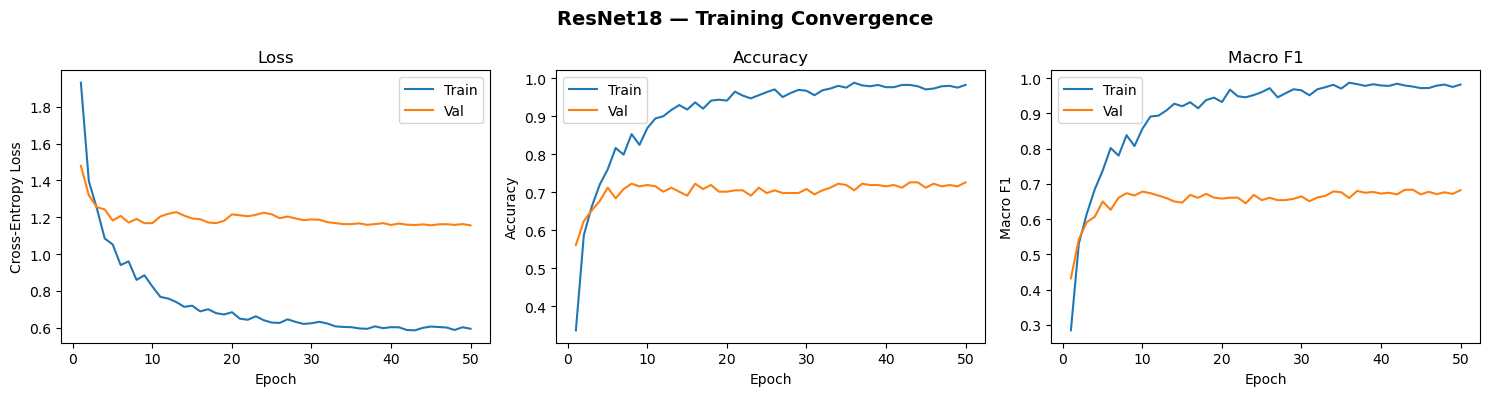

In [ ]:
dummy = ArtistStyleClassifier(num_classes=8, pretrained=False)
_, _, _, _, _, history_resnet = load_checkpoint(
    CKPT / "resnet18_last_checkpoint.pth", dummy, map_location="cpu")

plot_supervised(history_resnet, "ResNet18 — Training Convergence",
                REPORTS / "convergence_resnet18.png")


## EfficientNet B0

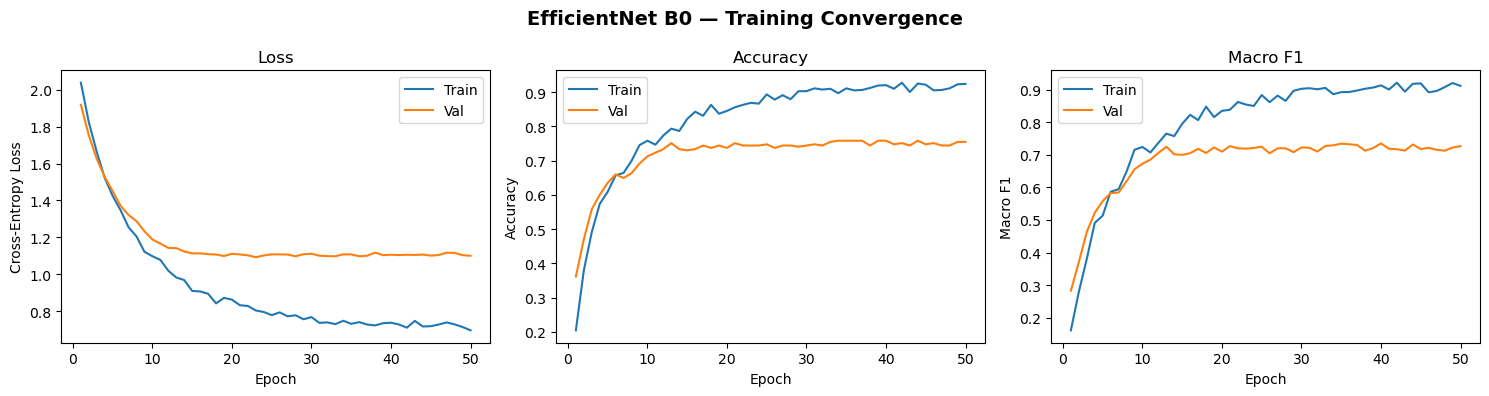

In [ ]:
dummy = EfficientNetClassifier(num_classes=8, pretrained=False)
_, _, _, _, _, history_eff = load_checkpoint(
    CKPT / "efficientnet_last_checkpoint.pth", dummy, map_location="cpu")

plot_supervised(history_eff, "EfficientNet B0 — Training Convergence",
                REPORTS / "convergence_efficientnet.png")


## SimCLR (SSL)

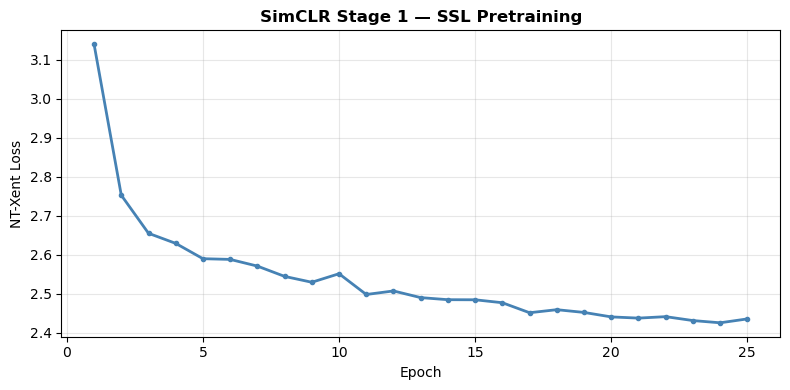

In [ ]:
dummy = SimCLR(pretrained=False)
_, _, _, _, _, history_ssl = load_checkpoint(
    CKPT / "ssl_last.pt", dummy, map_location="cpu")

ssl_losses = history_ssl["ssl_losses"]
ep = range(1, len(ssl_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ep, ssl_losses, color="steelblue", linewidth=2, marker="o", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("NT-Xent Loss")
ax.set_title("SimCLR Stage 1 — SSL Pretraining", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS / "convergence_ssl_stage1.png", dpi=150, bbox_inches="tight")
plt.show()


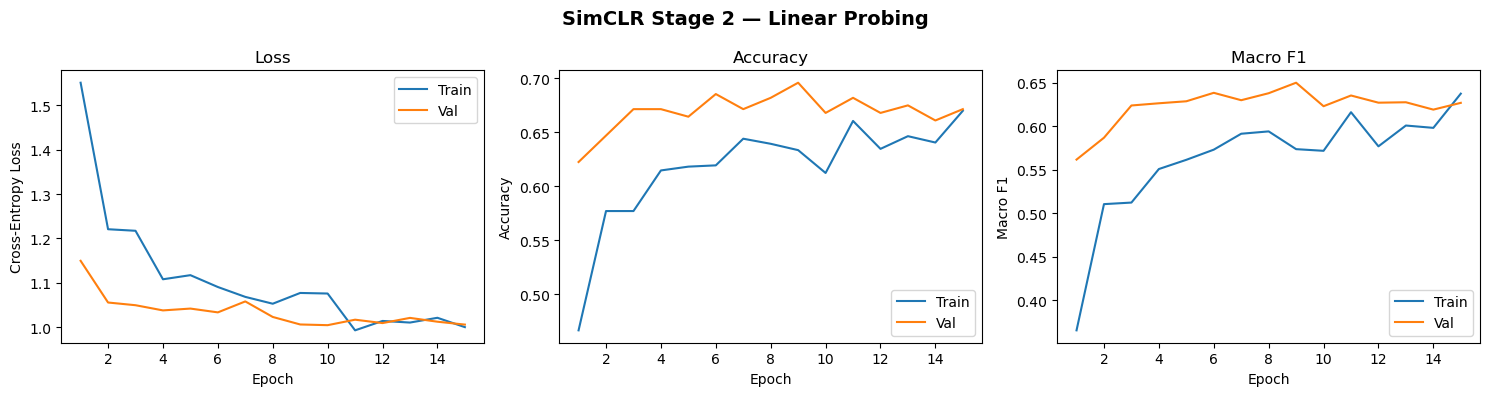

In [ ]:
dummy = torch.nn.ModuleDict({
    'backbone': SimCLR(pretrained=False).backbone,
    'classifier': LinearClassifier(512, 8),
})
_, _, _, _, _, history_probe = load_checkpoint(
    CKPT / "probe_last.pt", dummy, map_location="cpu")

plot_supervised(history_probe, "SimCLR Stage 2 — Linear Probing",
                REPORTS / "convergence_ssl_stage2.png")


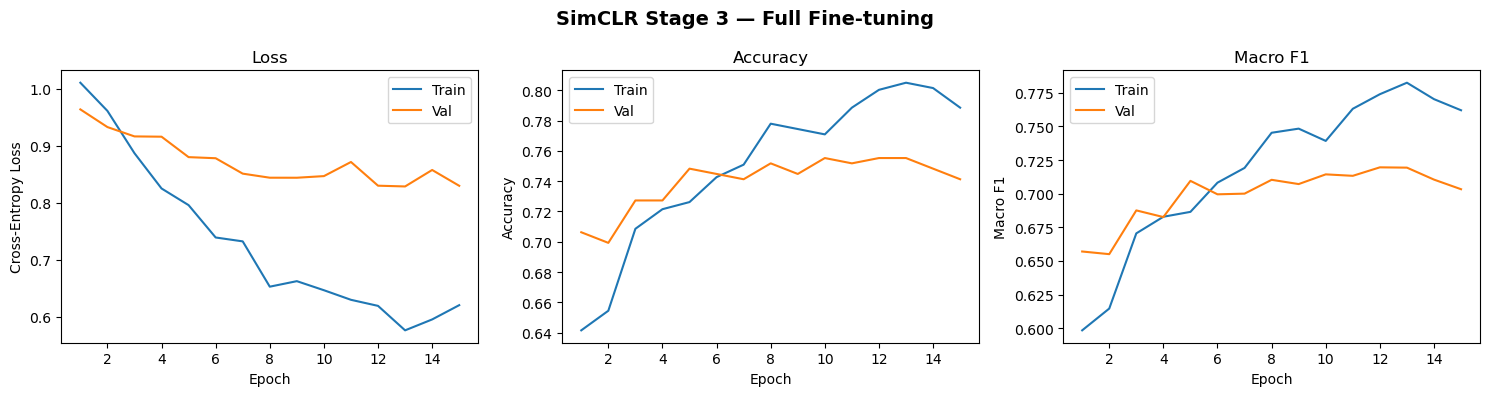

In [7]:
dummy = torch.nn.ModuleDict({
    'backbone': SimCLR(pretrained=False).backbone,
    'classifier': LinearClassifier(512, 8),
})
_, _, _, _, _, history_ft = load_checkpoint(
    CKPT / "ft_last.pt", dummy, map_location="cpu")

plot_supervised(history_ft, "SimCLR Stage 3 — Full Fine-tuning",
                REPORTS / "convergence_ssl_stage3.png")


## VAE

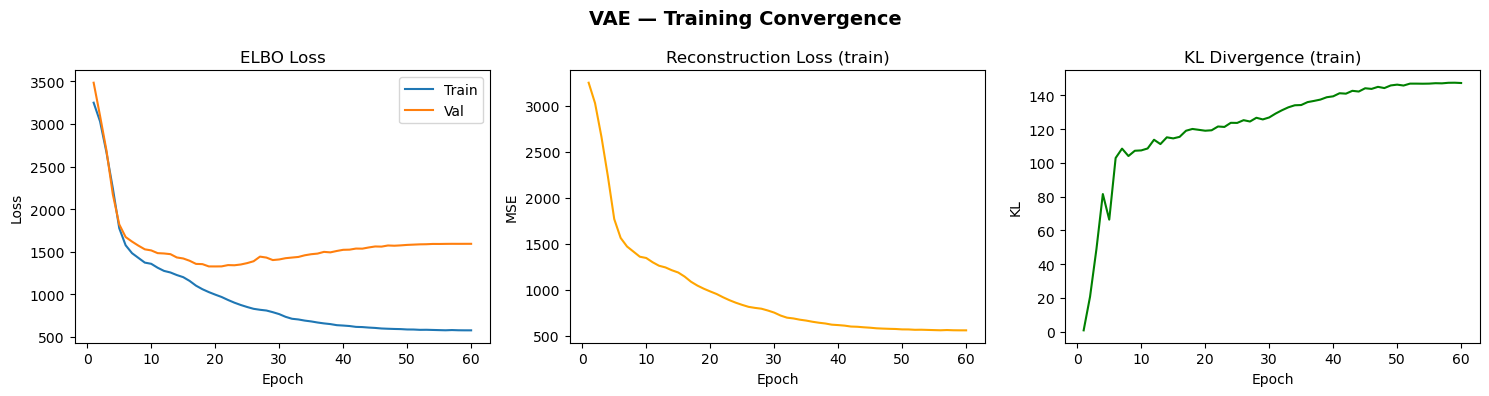

In [ ]:
dummy = ConvVAE(latent_dim=32, image_size=128)
_, _, _, _, _, history_vae = load_checkpoint(
    CKPT / "vae_last.pt", dummy, map_location="cpu")

ep = range(1, len(history_vae["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, history_vae["train_loss"], label="Train")
axes[0].plot(ep, history_vae["val_loss"], label="Val")
axes[0].set_title("ELBO Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(ep, history_vae["recon"], color="orange")
axes[1].set_title("Reconstruction Loss (train)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")

axes[2].plot(ep, history_vae["kl"], color="green")
axes[2].set_title("KL Divergence (train)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("KL")

fig.suptitle("VAE — Training Convergence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS / "convergence_vae.png", dpi=150, bbox_inches="tight")
plt.show()


## Test Set Evaluation

In [ ]:
test_clf_dataset = PaintingStyleDataset(
    PROJECT_ROOT / "data" / "test",
    transform=get_transforms("test", 128),
)
test_clf_loader = DataLoader(test_clf_dataset, batch_size=32,
                             shuffle=False, num_workers=0)
criterion = torch.nn.CrossEntropyLoss()

model_resnet, _, _, _, _, _ = load_checkpoint(
    CKPT / "resnet18_best_checkpoint.pth",
    ArtistStyleClassifier(num_classes=8, pretrained=False).to(device),
    optimizer=None, map_location=str(device),
)
_, metrics_resnet = engine.evaluate(model_resnet, test_clf_loader, criterion, device)
del model_resnet
torch.mps.empty_cache()

model_eff, _, _, _, _, _ = load_checkpoint(
    CKPT / "efficientnet_best_checkpoint.pth",
    EfficientNetClassifier(num_classes=8, pretrained=False).to(device),
    optimizer=None, map_location=str(device),
)
_, metrics_eff = engine.evaluate(model_eff, test_clf_loader, criterion, device)
del model_eff
torch.mps.empty_cache()

_ssl = SimCLR(pretrained=False)
_ssl_combined, _, _, _, _, _ = load_checkpoint(
    CKPT / "ft_best.pt",
    torch.nn.ModuleDict({
        'backbone':   _ssl.backbone,
        'classifier': LinearClassifier(_ssl.feature_dim, 8),
    }).to(device),
    optimizer=None, map_location=str(device),
)
_, metrics_ssl = classifier_evaluate(
    _ssl_combined['backbone'], _ssl_combined['classifier'],
    test_clf_loader, criterion, device,
)
del _ssl_combined
torch.mps.empty_cache()

print(f"ResNet18 - Accuracy: {metrics_resnet['accuracy']:.3f}  Macro F1: {metrics_resnet['macro_f1']:.3f}")
print(f"EfficientNet - Accuracy: {metrics_eff['accuracy']:.3f}  Macro F1: {metrics_eff['macro_f1']:.3f}")
print(f"SimCLR - Accuracy: {metrics_ssl['accuracy']:.3f}  Macro F1: {metrics_ssl['macro_f1']:.3f}")

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

ResNet18 - Accuracy: 0.762  Macro F1: 0.716
EfficientNet - Accuracy: 0.745  Macro F1: 0.711
SimCLR - Accuracy: 0.755  Macro F1: 0.720


## Model Comparison

In [ ]:
vae_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])
test_dataset = PaintingStyleDataset(
    PROJECT_ROOT / "data" / "test", transform=vae_transform)
test_loader = DataLoader(test_dataset, batch_size=32,
                         shuffle=False, num_workers=0)

In [7]:
vae, _, _, _, _, _ = load_checkpoint(
    CKPT / "vae_best.pt",
    ConvVAE(latent_dim=32, image_size=128),
    optimizer=None,
    map_location=str(device),
)
vae.eval()

test_mu, test_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        mu, _ = vae.encode(imgs)
        test_mu.append(mu.cpu())
        test_labels.extend(lbls.numpy())
test_mu = torch.cat(test_mu).numpy()
test_labels = np.array(test_labels)

In [ ]:
raw = joblib.load(CKPT / "xgboost.pkl")
print(type(raw))

<class 'dict'>


In [9]:
ckpt_xgb = joblib.load(CKPT / "xgboost.pkl")
xgb    = ckpt_xgb["model"]
scaler = ckpt_xgb["scaler"]

xgb.set_params(nthread=1)

test_mu_scaled = scaler.transform(test_mu)
xgb_pred = xgb.predict(test_mu_scaled)

xgb_acc = accuracy_score(test_labels, xgb_pred)
xgb_f1  = f1_score(test_labels, xgb_pred, average="macro")
print(f"VAE + XGBoost — Accuracy: {xgb_acc:.3f}  Macro F1: {xgb_f1:.3f}")

VAE + XGBoost — Accuracy: 0.350  Macro F1: 0.308


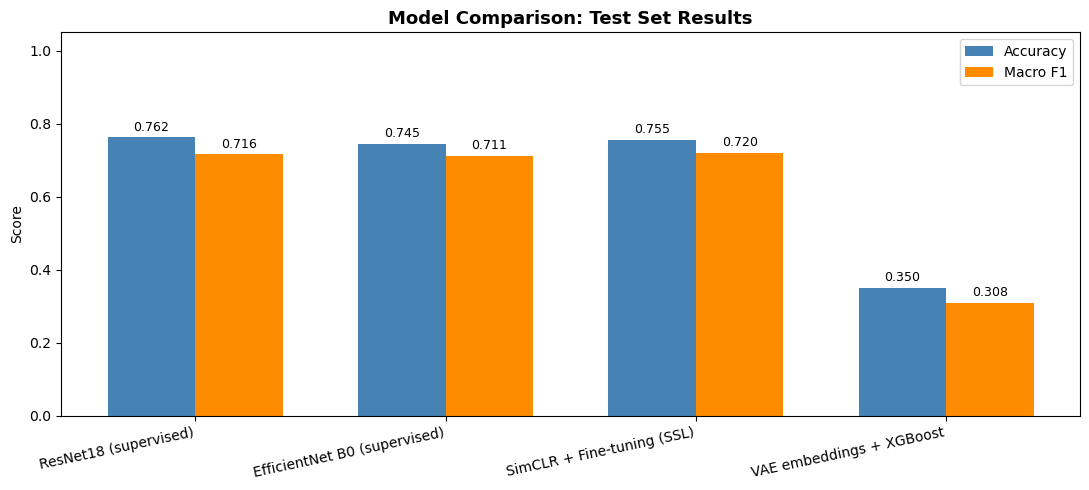

Model                                      Accuracy   Macro F1
--------------------------------------------------------------
ResNet18 (supervised)                         0.762      0.716
EfficientNet B0 (supervised)                  0.745      0.711
SimCLR + Fine-tuning (SSL)                    0.755      0.720
VAE embeddings + XGBoost                      0.350      0.308

Saved: /Users/arpinejanunts/Desktop/iml2-painting-style/reports/model_comparison.png
Saved: /Users/arpinejanunts/Desktop/iml2-painting-style/reports/model_comparison.csv


In [ ]:
results = {
    "ResNet18 (supervised)":        {"accuracy": metrics_resnet["accuracy"], "macro_f1": metrics_resnet["macro_f1"]},
    "EfficientNet B0 (supervised)": {"accuracy": metrics_eff["accuracy"],    "macro_f1": metrics_eff["macro_f1"]},
    "SimCLR + Fine-tuning (SSL)":   {"accuracy": metrics_ssl["accuracy"],    "macro_f1": metrics_ssl["macro_f1"]},
    "VAE embeddings + XGBoost":     {"accuracy": xgb_acc,                   "macro_f1": xgb_f1},
}

models = list(results.keys())
accuracies = [results[m]["accuracy"] for m in models]
f1_scores  = [results[m]["macro_f1"]  for m in models]
x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar([i - width/2 for i in x], accuracies, width, label="Accuracy", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], f1_scores,  width, label="Macro F1",  color="darkorange")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=12, ha="right", fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Test Set Results", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

with open(REPORTS / "model_comparison.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Model", "Accuracy", "Macro F1"])
    for model, m in results.items():
        writer.writerow([model, round(m["accuracy"], 4), round(m["macro_f1"], 4)])

print(f"{'Model':<40} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 62)
for model, m in results.items():
    print(f"{model:<40} {m['accuracy']:>10.3f} {m['macro_f1']:>10.3f}")

print(f"\nSaved: {REPORTS / 'model_comparison.png'}")
print(f"Saved: {REPORTS / 'model_comparison.csv'}")
